# IRIS dataset classification using ANN

In 1936, the British statistician and biologist Ronald Fisher published The use of multiple measurements in taxonomic problems as an example of linear discriminant analysis.

Two of the three species were collected on the Gaspé Peninsula "all from the same pasture, collected on the same day and measured at the same time by the same person with the same instrument".

The dataset consists of 50 samples from each of the three species of iris.

Four traits were measured for each sample: length and width of calyx and petals in centimetres. 

Identification of the fescue species by the dimensions of the different petals

- https://en.wikipedia.org/wiki/Iris_flower_data_set
- https://www.kaggle.com/arshid/iris-flower-dataset

# Task

Your goal is to create a classification neural network to distinguish different species of killer whales.

We will use the same data as in the k-means/SVM chapter, you can build on it.

As you work through this task, the following points will be completed in turn:

- Retrieve the data and display the basic statistics
- Use binary encoding to prepare the data.
- Standardize the input values using StandardScaler
- Split the data into training, test and validation

- Create a neural network model, don't be afraid to experiment with the number of hidden layers and their size
- You will probably need Dense layers, you can try the Drop layer
- Use a relay as the activation function, use a Softmax layer for the output

- When learning, use the categorical_crossentropy cost function
- The optimization algorithm will be ADAM
- You can collect other accuracy metrics

- Save the learned model to a file

- Test the learned model, find R2 and accuracy
- Plot the substitution matrix

- Plot the learning history

- Test the model on your input data (create inference)

# Data retrieval and basic statistics
- data preview
- basic statistics
- NULL values

In [10]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, r2_score
import keras
from keras.layers import Dense, Dropout, Input
from keras.models import Sequential
from keras.utils import to_categorical

In [11]:
data=pd.read_csv('..\dataset\IRIS.csv')

In [12]:
print("DATA PREVIEW")
print(data.head())
print()

print("BASIC STATISTICS")
print(data.describe())
print()

print("DATA INFO")
print(data.info())
print()

print("NULL VALUES")
print(data.isnull().sum())
print()

print("SPECIES DISTRIBUTION")
print(data['species'].value_counts())
print()

DATA PREVIEW
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

BASIC STATISTICS
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

DATA INFO
<cla

# Data visualization
- distribution of values

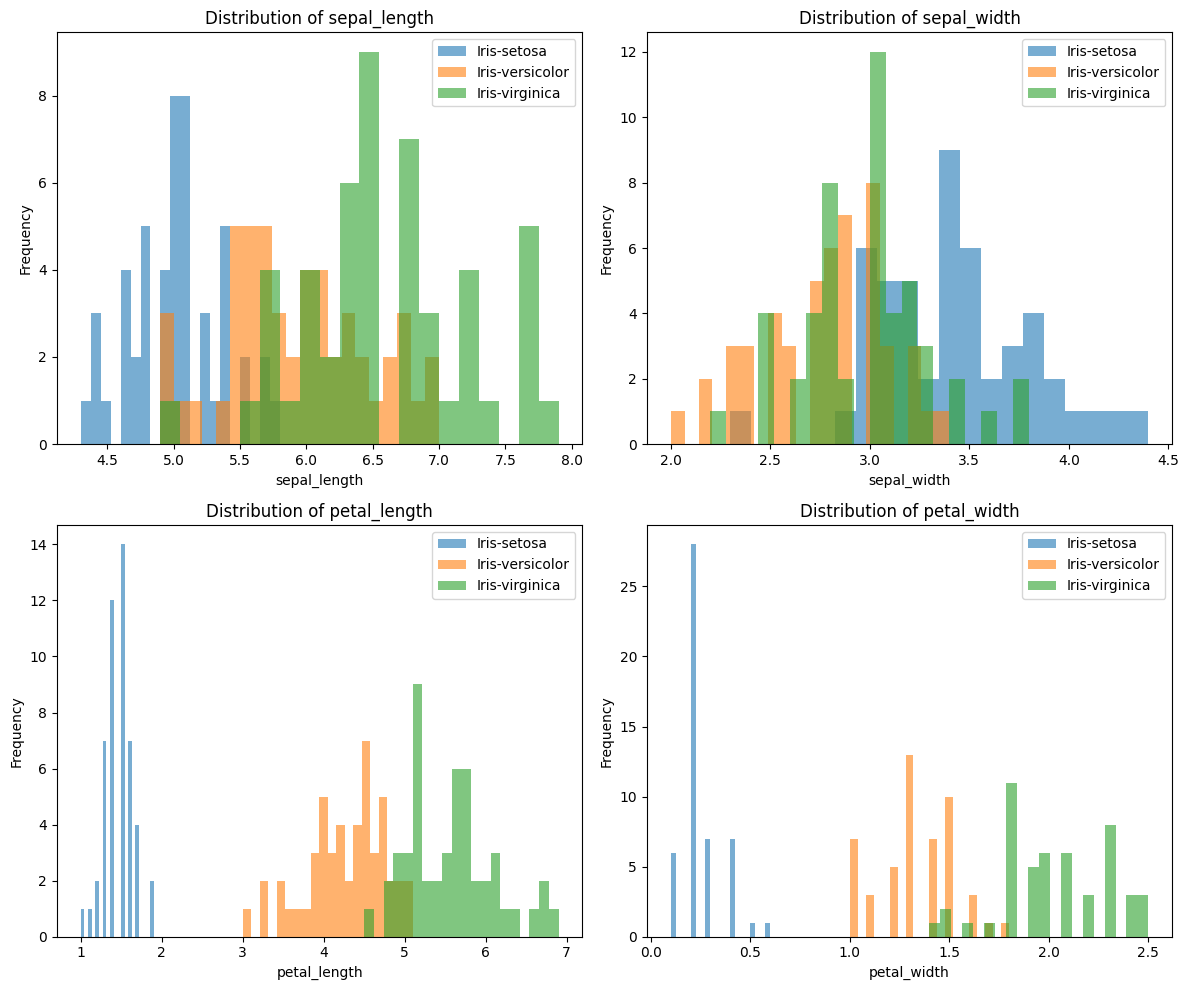

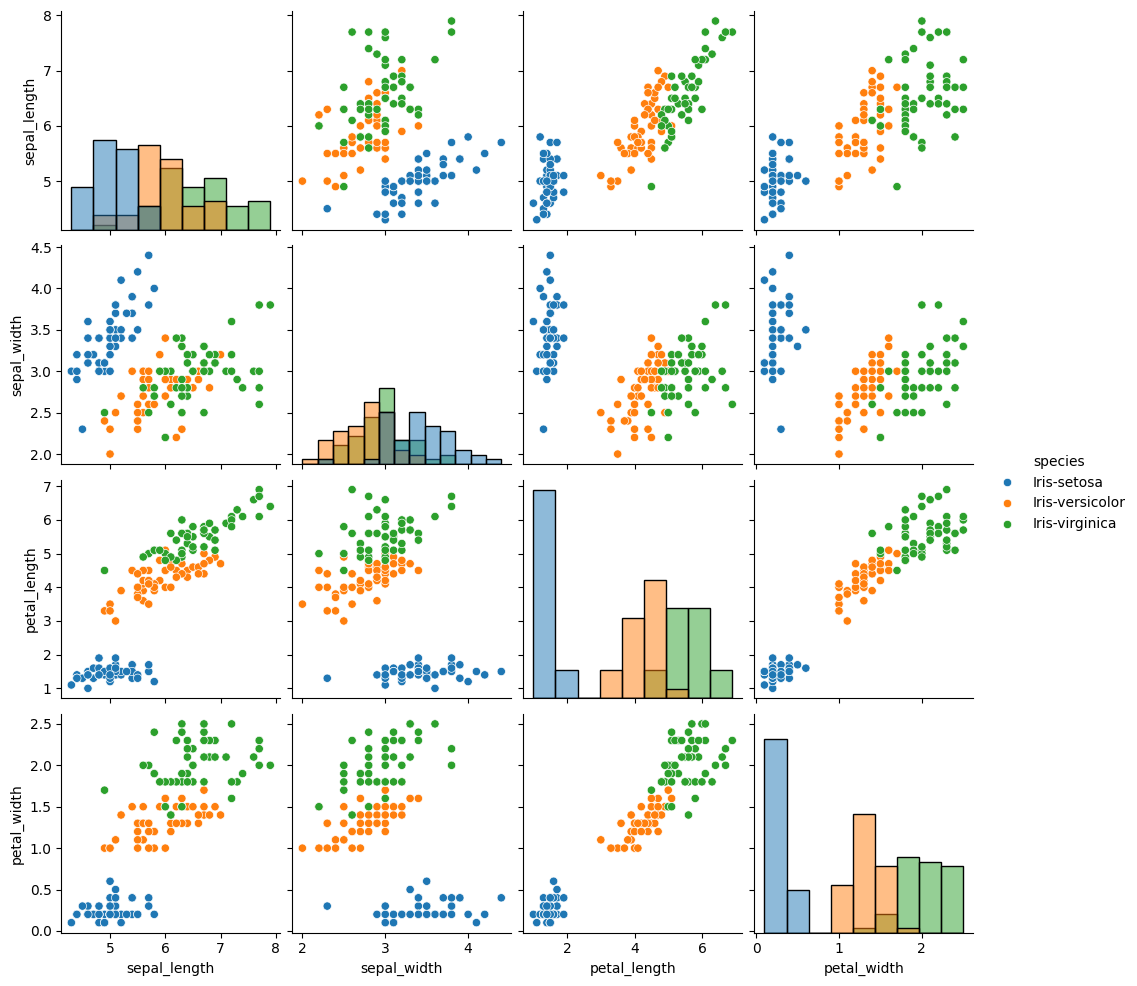

In [13]:
# Distribution of values
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for idx, feature in enumerate(features):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    for species in data['species'].unique():
        subset = data[data['species'] == species]
        ax.hist(subset[feature], alpha=0.6, label=species, bins=20)
    
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {feature}')
    ax.legend()

plt.tight_layout()
plt.show()

# Pairplot
sns.pairplot(data, hue='species', diag_kind='hist')
plt.show()


# Data preparation
- binary encoding
- standardization of input variables

In [14]:
# Separate features and target
X = data[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = data['species'].values

# Binary encoding - convert species names to numbers
species_mapping = {species: idx for idx, species in enumerate(data['species'].unique())}
print("SPECIES MAPPING")
print(species_mapping)
print()

y_numeric = np.array([species_mapping[species] for species in y])

# One-hot encoding for neural network
y_encoded = to_categorical(y_numeric, num_classes=3)

print("Original label:", y[0])
print("Numeric label:", y_numeric[0])
print("One-hot encoded:", y_encoded[0])
print()

# Standardization of input variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("STANDARDIZATION")
print("Original data (first sample):", X[0])
print("Scaled data (first sample):", X_scaled[0])
print()

# Split data into train, validation, and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_numeric
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)

print("DATA SPLIT")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print()

SPECIES MAPPING
{'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}

Original label: Iris-setosa
Numeric label: 0
One-hot encoded: [1. 0. 0.]

STANDARDIZATION
Original data (first sample): [5.1 3.5 1.4 0.2]
Scaled data (first sample): [-0.90068117  1.03205722 -1.3412724  -1.31297673]

DATA SPLIT
Training set: 96 samples
Validation set: 24 samples
Test set: 30 samples



## Neural network modelling

Neural network model
* Sequential model - data flows from the input layer through hidden layers to the output layer.
* Dense layer connects each neuron from the previous layer to each neuron in the layer.
* Drop layer randomly sets the input units to 0 at each step during the training period, which helps prevent overfitting.
* RELU and Softmax activation functions are used. 
* The last Softmax function is used in the output layer because this project is a classification project.

* Compilation is the last step in model building.
* The optimizer we use is Adam. Adam is an optimization algorithm that can be used instead of the classical stochastic gradient descent procedure to iteratively update the network weights based on the training data.
* Cost function - categorical_crossentropy, a special loss function for classification (https://keras.io/api/losses/probabilistic_losses/#categoricalcrossentropy-class).
* Another metric - Accuracy - is computed during learning.


Model: "sequential"
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                80                                                                         
 dropout (Dropout)           (None, 16)                0                                                                          
 dense_1 (Dense)             (None, 16)                272                                                                        
 dropout_1 (Dropout)         (None, 16)                0                                                                          
 dense_2 (Dense)             (None, 3)                 51        
                                                                 
Total params: 403
Trainable params: 403
Non-trainable params: 0

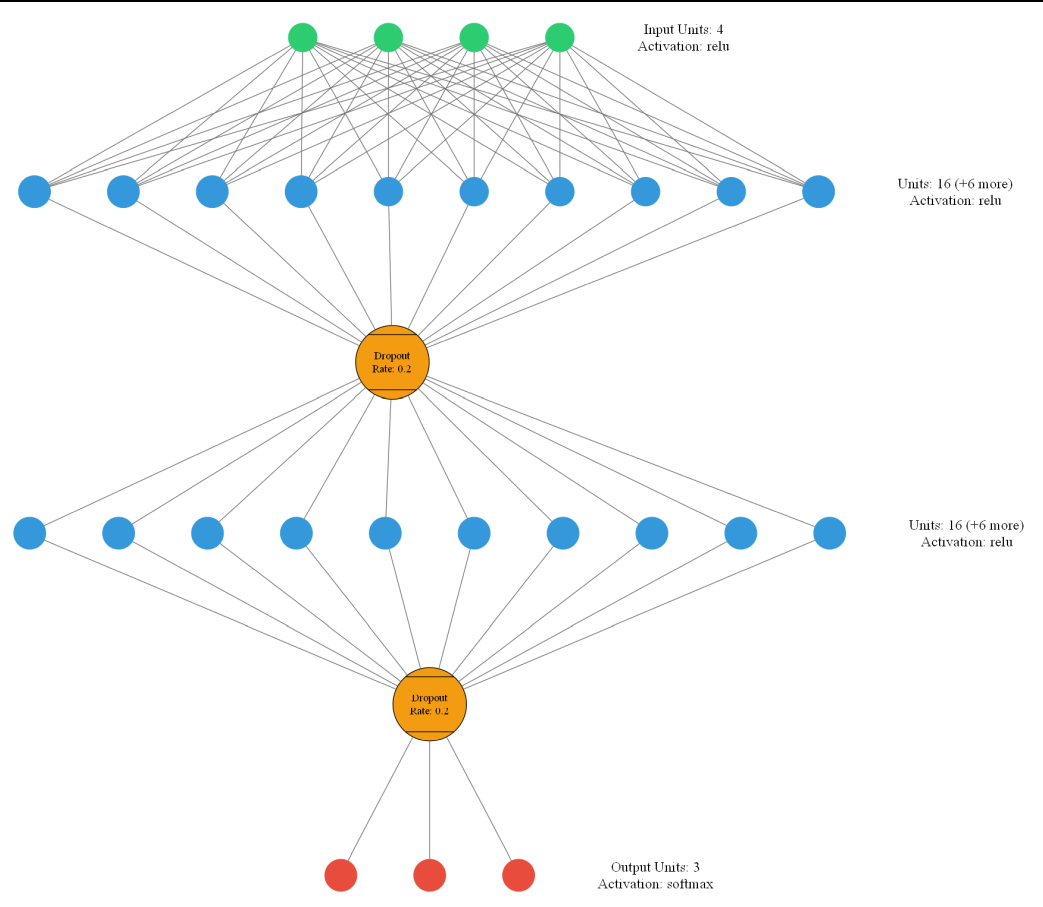

In [15]:
model = Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(3, activation='softmax'))

# Compile model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("MODEL SUMMARY")
model.summary()
print()

MODEL SUMMARY


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403 (1.57 KB)

 Trainable params: 403 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=30,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8438 - loss: 0.3622 - val_accuracy: 0.8750 - val_loss: 0.3803
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8854 - loss: 0.3622 - val_accuracy: 0.8750 - val_loss: 0.3755
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8542 - loss: 0.3328 - val_accuracy: 0.8750 - val_loss: 0.3708
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9271 - loss: 0.3214 - val_accuracy: 0.8750 - val_loss: 0.3658
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9062 - loss: 0.3534 - val_accuracy: 0.8750 - val_loss: 0.3613
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9271 - loss: 0.2929 - val_accuracy: 0.8750 - val_loss: 0.3567
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9062 - loss: 0.3354 - val_accuracy: 0.8750 - val_loss: 0.3518
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8958 - loss: 0.3124 - val_accuracy: 0.8333 - val_loss:

# Save the model

In [16]:
model.save('iris_classification_model.keras')
print("Model saved as 'iris_classification_model.keras'")
print()

Model saved as 'iris_classification_model.keras'



# Show learning history

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.2292 - loss: 1.2319 - val_accuracy: 0.2500 - val_loss: 1.1506
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2396 - loss: 1.2088 - val_accuracy: 0.2917 - val_loss: 1.0957
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3333 - loss: 1.0949 - val_accuracy: 0.5833 - val_loss: 1.0462
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4167 - loss: 1.0282 - val_accuracy: 0.6250 - val_loss: 1.0023
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4167 - loss: 1.0262 - val_accuracy: 0.6250 - val_loss: 0.9599
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5208 - loss: 0.9406 - val_accuracy: 0.6250 - val_loss: 0.9180
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5833 - loss: 0.9220 - val_accuracy: 0.6250 - val_loss: 0.8793
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6042 - loss: 0.8943 - val_accuracy: 0.6250 - val_loss: 

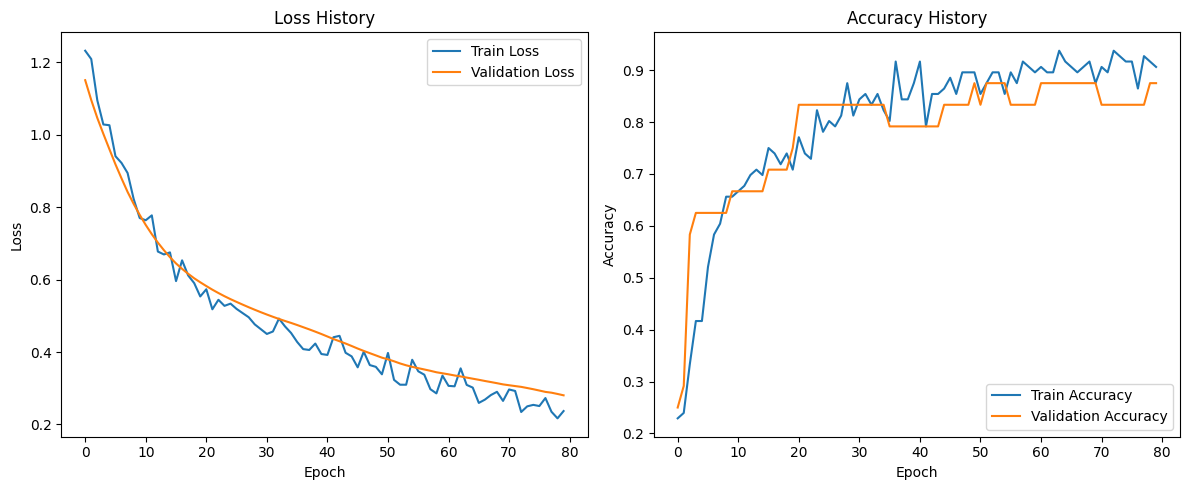

In [ ]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss History')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy History')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.tight_layout()
plt.show()

# Model Verification
- Prediction of test values
- Accuracy
- Confusion matrix of training and test data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
MODEL EVALUATION
Test Accuracy: 0.2333
R2 Score: -0.0448



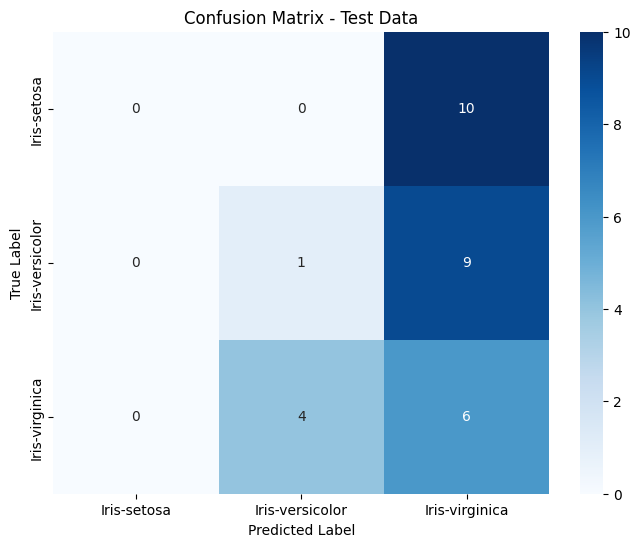

In [9]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Accuracy
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print("MODEL EVALUATION")
print(f"Test Accuracy: {accuracy:.4f}")

# R2 score (note: R2 is typically for regression, but we can calculate it)
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2:.4f}")
print()

# Confusion Matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(species_mapping.keys()),
            yticklabels=list(species_mapping.keys()))
plt.title('Confusion Matrix - Test Data')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


# Using the model
The answer should therefore be Iris virginica

In [ ]:
new_data_raw = np.array([[1, 2, 1, 2]])

new_data_scaled = scaler.transform(new_data_raw)

test_predictions = model.predict(new_data_scaled)

print(f"Iris setosa:     {test_predictions[0][0]:.4f}")
print(f"Iris versicolor: {test_predictions[0][1]:.4f}")
print(f"Iris virginica:  {test_predictions[0][2]:.4f}")

classes = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
winner = np.argmax(test_predictions)
print(f"\nPredicted: {classes[winner]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Iris setosa:     0.9923
Iris versicolor: 0.0070
Iris virginica:  0.0007

Predicted: Iris-setosa
